# Project Objective
## The goal of this project is to analyze Airbnb NYC listing data to understand the key factors influencing listing prices.
- This includes:
    - Cleaning and preprocessing raw data
    - Handling missing values and outliers
    - Transforming skewed features
    - Creating meaningful features such as price categories, host types, and availability ratios

The final dataset will be structured and ready for exploratory analysis and future modeling tasks.

# Load The Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv')

In [3]:
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# Data Cleaning and Preparation

In [4]:
def feature_summary(df):
    summary = pd.DataFrame({
        'dtype' : df.dtypes,
        'missing_count' : df.isnull().sum(),
        'missing_percent' : (df.isnull().sum() / len(df)) * 100,
        'unique_values' : df.nunique(),
        'duplicate values': df.apply(lambda x: x.duplicated().sum()),
        'memory_MB' : df.memory_usage(index = False, deep = True) / (1024**2)
    })
    return summary.sort_values(by = 'missing_percent', ascending = False)

feature_summary(df)

,dtype,missing_count,missing_percent,unique_values,duplicate values,memory_MB
last_review,object,10052,20.558339,1764,47130,2.492333
reviews_per_month,float64,10052,20.558339,937,47957,0.373039
host_name,object,21,0.042949,11452,37442,2.575267
name,object,16,0.032723,47905,989,4.060271
neighbourhood_group,object,0,0.000000,5,48890,2.666412
neighbourhood,object,0,0.000000,221,48674,2.839519
id,int64,0,0.000000,48895,0,0.373039
host_id,int64,0,0.000000,37457,11438,0.373039
longitude,float64,0,0.000000,14718,34177,0.373039
latitude,float64,0,0.000000,19048,29847,0.373039


In [5]:
df_clean = df.copy()
df_clean = df_clean.drop(columns = ['name','host_name','id','host_id','last_review'], axis = 1)
df_clean.head(5)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [6]:
def feature_summary(df):
    summary = pd.DataFrame({
        'dtype' : df.dtypes,
        'missing_count' : df.isnull().sum(),
        'missing_percent' : (df.isnull().sum() / len(df)) * 100,
        'unique_values' : df.nunique(),
        'duplicate values': df.apply(lambda x: x.duplicated().sum()),
        'memory_MB' : df.memory_usage(index = False, deep = True) / (1024**2)
    })
    return summary.sort_values(by = 'missing_percent', ascending = False)

feature_summary(df_clean)

,dtype,missing_count,missing_percent,unique_values,duplicate values,memory_MB
reviews_per_month,float64,10052,20.558339,937,47957,0.373039
neighbourhood,object,0,0.000000,221,48674,2.839519
neighbourhood_group,object,0,0.000000,5,48890,2.666412
latitude,float64,0,0.000000,19048,29847,0.373039
longitude,float64,0,0.000000,14718,34177,0.373039
price,int64,0,0.000000,674,48221,0.373039
room_type,object,0,0.000000,3,48892,2.916014
minimum_nights,int64,0,0.000000,109,48786,0.373039
number_of_reviews,int64,0,0.000000,394,48501,0.373039
calculated_host_listings_count,int64,0,0.000000,47,48848,0.373039


## Summary
- I have dropped column `name` as its just listing title(text) and there is no consistent pattern for analysis and host name is dropped because of this same reason.
- Column `id` had Unique Identifier but no analytical value.
- Column `host_id` is again an identifier but we already have `calculated_host_listings_count` for host behavior.
- Now there are 2 methods to handle `last_review` on is to drop it as it is no use right now or if we are doing time_series analysis, we need to convert the column into "Days since last review" so that it makes more meaning but this adds more complexity so I thought of removing it for now as  I am not focusing on time series right now.

# Handling Missing Values

In [7]:
df_clean.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [9]:
df_clean.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## Summary
- Only `review_per_month` had missing values, the feature we need (~20%)
- Everything is already clean.
- Here missing values does not mean that there is an error. It means that listing has no review yet.
- So the best choice over here will be to replace the value with 0.
- Here its best we don't replace the value with mean, median as it will create false activity.

# Handle Outliers

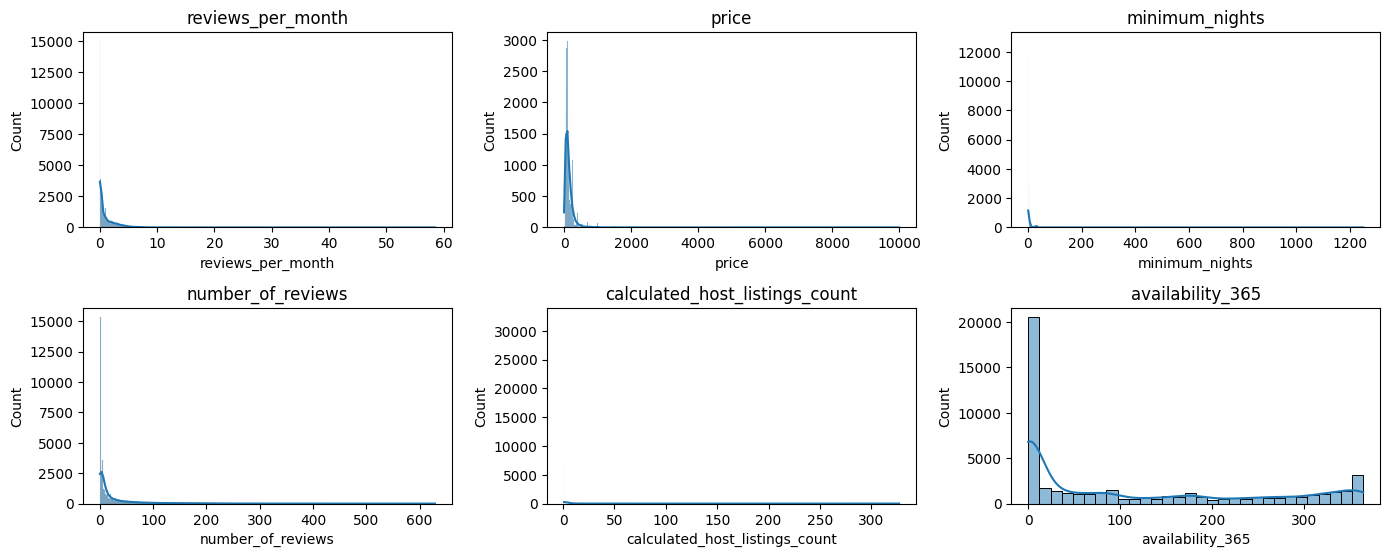

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col = [
    'reviews_per_month',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'calculated_host_listings_count',
    'availability_365'
]

plt.figure(figsize = (14,8))

for i, col in enumerate(num_col, 1):
    plt.subplot(3,3,i),
    sns.histplot(df_clean[col], kde = True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
# Handling outliers for feature price using 99th percentile approach:
p99 = df_clean['price'].quantile(0.99)
df_clean['price'] = df_clean['price'].clip(upper = p99)

In [12]:
# Handling outliers for minimum nights using 99th percentile approach
p99 = df_clean['minimum_nights'].quantile(0.99)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper = p99)

In [13]:
# Handling outliers for calculated_host_listings_count using the 99th percentile appraoch
p99 = df_clean['calculated_host_listings_count'].quantile(0.99)
df_clean['calculated_host_listings_count'] = df_clean['calculated_host_listings_count'].clip(p99)

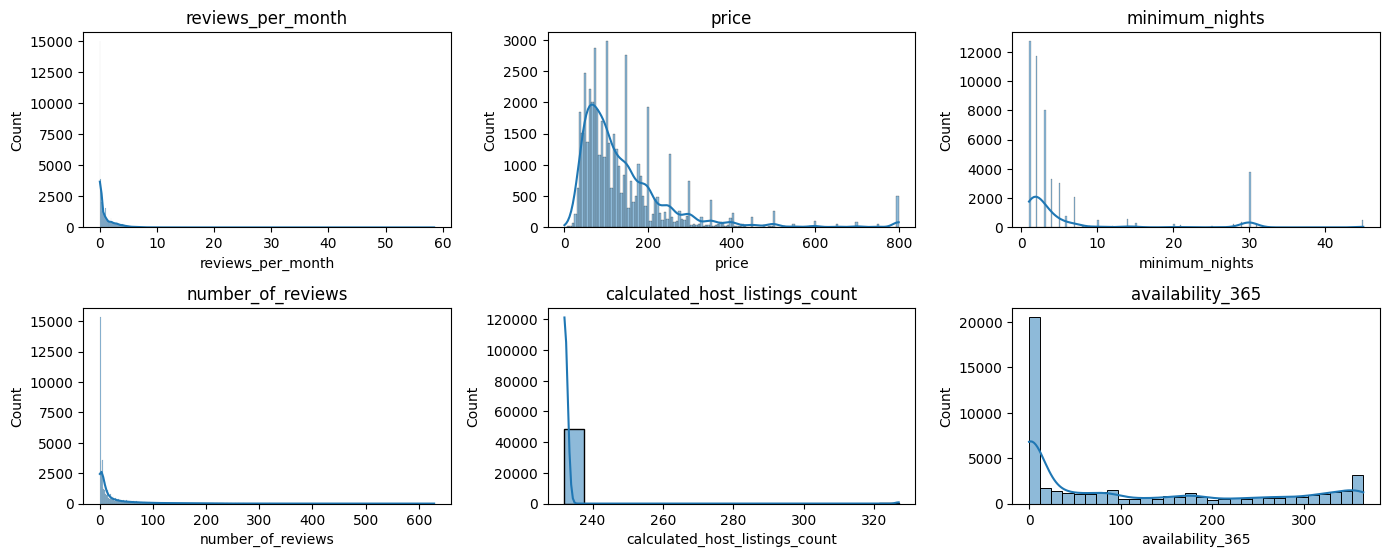

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col = [
    'reviews_per_month',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'calculated_host_listings_count',
    'availability_365'
]

plt.figure(figsize = (14,8))

for i, col in enumerate(num_col, 1):
    plt.subplot(3,3,i),
    sns.histplot(df_clean[col], kde = True)
    plt.title(col)

plt.tight_layout()
plt.show()

## Summary
- The dataset exhibited significant skewness and extreme values across several numerical features, particularly `price`, `minimum_nights` and `calculated_host_listings_count`.
- To mitigate the impact of these extreme values without losing important data, a 99th percentile capping approach is used. This has helped me reduce the influence of usually high values while preserving the overall structure of the dataset.
- The feature such as `reviews_per_month` and `number_of_reviews` also showed high variability, however these values represent genuine user actibity and listing popularity. Therefore no aggressive outlier treatment was applied to these features to retain meaningful information.
- Even after capping certain values still appear as outliers due to IQR based defination of outliers. This are considered part of natural data variation rather than anomalies and no further removal is required.

# Feature Transformation

## Log Transformation

In [15]:
# Log transforming the data as it was skewed.
df_clean['log_price'] = np.log1p(df_clean['price'])

In [16]:
#Similarly log transforming number of reviews
df_clean['log_number_of_review'] = np.log1p(df_clean['number_of_reviews'])

In [17]:
df_clean[['log_price','price','log_number_of_review','number_of_reviews']].head()

,log_price,price,log_number_of_review,number_of_reviews
0,5.010635,149,2.302585,9
1,5.420535,225,3.828641,45
2,5.017280,150,0.000000,0
3,4.499810,89,5.602119,270
4,4.394449,80,2.302585,9


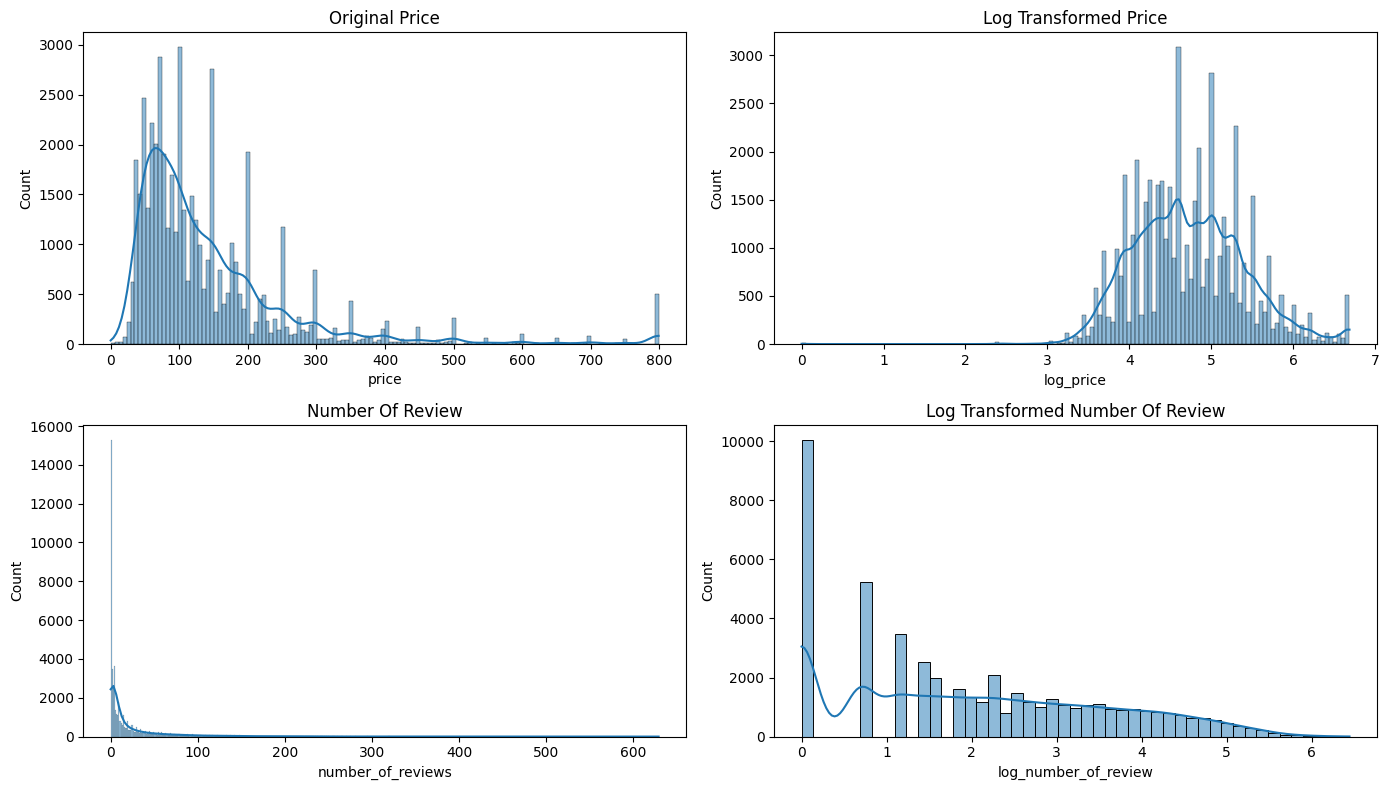

In [18]:
plt.figure(figsize = (14,8))

plt.subplot(2,2,1)
sns.histplot(df_clean['price'], kde = True)
plt.title('Original Price')

plt.subplot(2,2,2)
sns.histplot(df_clean['log_price'], kde = True)
plt.title('Log Transformed Price')

plt.subplot(2,2,3)
sns.histplot(df_clean['number_of_reviews'], kde = True)
plt.title('Number Of Review')

plt.subplot(2,2,4)
sns.histplot(df_clean['log_number_of_review'], kde = True)
plt.title('Log Transformed Number Of Review')

plt.tight_layout()

### Summary
- Over here i have Log Transformed the `Price` as its highly skewed and log transformation makes it more usable
- Same goes for `Number of reviews` feature.
- We did not log transform `reviews_per_month` as there are many values that are zeros and log won't add much value. `minimum_nights` have discrete values so its better for binning them instead of log transform.
- for `calculated_host_listing_count`, its better that we use host type(single/multiple) and for `availability_365`, its already bounded thus we convert it into ratio.

## Bounded Feature

In [19]:
df_clean['availability_365_ratio'] = (df_clean['availability_365'] / 365).round(2)

In [20]:
df_clean[['availability_365','availability_365_ratio']].head()

,availability_365,availability_365_ratio
0,365,1.00
1,355,0.97
2,365,1.00
3,194,0.53
4,0,0.00


### Summary
- Here we have normalized this feature using the ratio.
- Here if we have the value as 1 that means that the listing is available through out the year. If its 0.5 that means its available for half a year and if its 0 that means its not available at all.
- This improves interpretability and brings the feature to consistent scale. 

## Feature Binning

In [21]:
# Price Category
df_clean['price_category'] = pd.cut(
    df_clean['price'],
    bins = [0, 100, 300, df_clean['price'].max()],
    labels = ['Budget', 'Mid - range','Premium']
)

In [22]:
df_clean[df_clean['price_category'].isna()]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,log_number_of_review,availability_365_ratio,price_category
23161,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,0.05,232,28,0.0,0.693147,0.08,NaN
25433,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2.56,232,127,0.0,4.025352,0.35,NaN
25634,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,0.71,232,0,0.0,2.833213,0.00,NaN
25753,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,0.53,232,0,0.0,2.564949,0.00,NaN
25778,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,0.15,232,73,0.0,1.386294,0.20,NaN
25794,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,4.28,232,176,0.0,4.543295,0.48,NaN
25795,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,4.37,232,232,0.0,4.564348,0.64,NaN
25796,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,4.35,232,222,0.0,4.564348,0.61,NaN
26259,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,0.00,232,0,0.0,0.000000,0.00,NaN
26841,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,0.11,232,333,0.0,1.098612,0.91,NaN


In [23]:
# In airbnb, there will be no such listings where they rent the place for free.
# So i am considering this as error and removing them from the dataset itself.
df_clean = df_clean[df_clean['price'] > 0]

In [24]:
df_clean['minimum_nights'].quantile([0.25,0.5,0.75])

0.25    1.0
0.50    3.0
0.75    5.0
Name: minimum_nights, dtype: float64

In [25]:
# minimum nights category
df_clean['min_night_category'] = pd.cut(
    df_clean['minimum_nights'],
    bins = [0,3,7,df_clean['minimum_nights'].max()],
    labels = ['short stay','medium stay','long stay']
)

In [26]:
# Availability category
df_clean['availability_category'] = pd.cut(
    df_clean['availability_365_ratio'],
    bins = [-0.01,0,0.3,0.7,1],
    labels = ['Not available','Low','Medium','High']
)

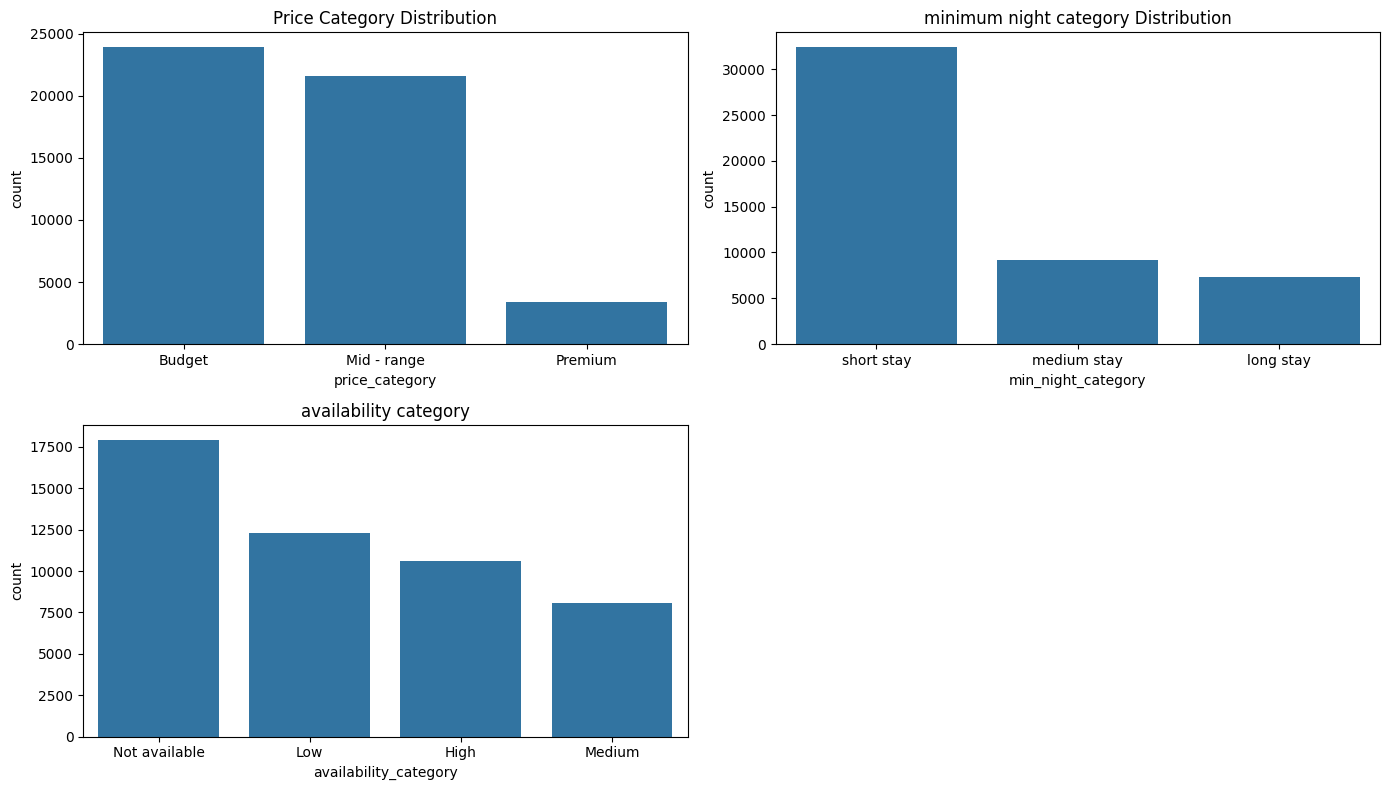

In [27]:
plt.figure(figsize = (14,8))
# Price Subcategory
plt.subplot(2,2,1)
sns.countplot(data = df_clean, x = 'price_category',order = df_clean['price_category'].value_counts().index)
plt.title('Price Category Distribution')

# Minimum Nights Category
plt.subplot(2,2,2)
sns.countplot(data = df_clean, x = 'min_night_category',order = df_clean['min_night_category'].value_counts().index)
plt.title('minimum night category Distribution')

# availability_category
plt.subplot(2,2,3)
sns.countplot(data = df_clean, x = 'availability_category',order = df_clean['availability_category'].value_counts().index)
plt.title('availability category')

plt.tight_layout()
plt.show()

In [28]:
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,log_number_of_review,availability_365_ratio,price_category,min_night_category,availability_category
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,232,365,5.010635,2.302585,1.00,Mid - range,short stay,High
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,232,355,5.420535,3.828641,0.97,Mid - range,short stay,High
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,232,365,5.017280,0.000000,1.00,Mid - range,short stay,High
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,232,194,4.499810,5.602119,0.53,Budget,short stay,Medium
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,232,0,4.394449,2.302585,0.00,Budget,long stay,Not available


### Summary
- To make the data easier to understand, some of the continuous features were grouped into meaningful categories. Instead of working with raw numbers, I created bins that reflect real-world scenarios — for example, splitting listings into budget, mid-range, and premium based on price, or categorizing stays into short, medium, and long durations based on minimum nights.
- While defining these ranges, I looked at both the data distribution and what makes sense practically, so the categories are not just mathematically correct but also intuitive. For availability, I also made sure to treat listings with zero availability separately, since they represent fully booked properties and behave differently from those with low availability.


## Derived Feature

In [29]:
# Lets first create a host type feature with respect to calculated_host_listings_count
df_clean['calculated_host_listings_count'].unique()

array([232, 327])

In [30]:
# Here i am using the original value of this column to replace the df_clean column as the value is wrongly transformed.
df_clean['calculated_host_listings_count'] = df['calculated_host_listings_count']

In [31]:
df_clean.head()
# Yep now its normal

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,log_number_of_review,availability_365_ratio,price_category,min_night_category,availability_category
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,2.302585,1.00,Mid - range,short stay,High
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,3.828641,0.97,Mid - range,short stay,High
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,0.000000,1.00,Mid - range,short stay,High
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,5.602119,0.53,Budget,short stay,Medium
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,2.302585,0.00,Budget,long stay,Not available


In [32]:
df_clean['host_type'] = df_clean['calculated_host_listings_count'].apply(
    lambda x: 'single' if x == 1 else 'Multiple'
)

In [33]:
# Now lets create the review_activity feature based on reviews_per_month
df_clean['review_activity'] = pd.cut(
    df_clean['reviews_per_month'],
    bins = [-0.01, 0, 1, 3, df_clean['reviews_per_month'].max()],
    labels = ['No reviews', 'Low', 'Medium', 'High']
)

Text(0.5, 1.0, 'review frequency per month')

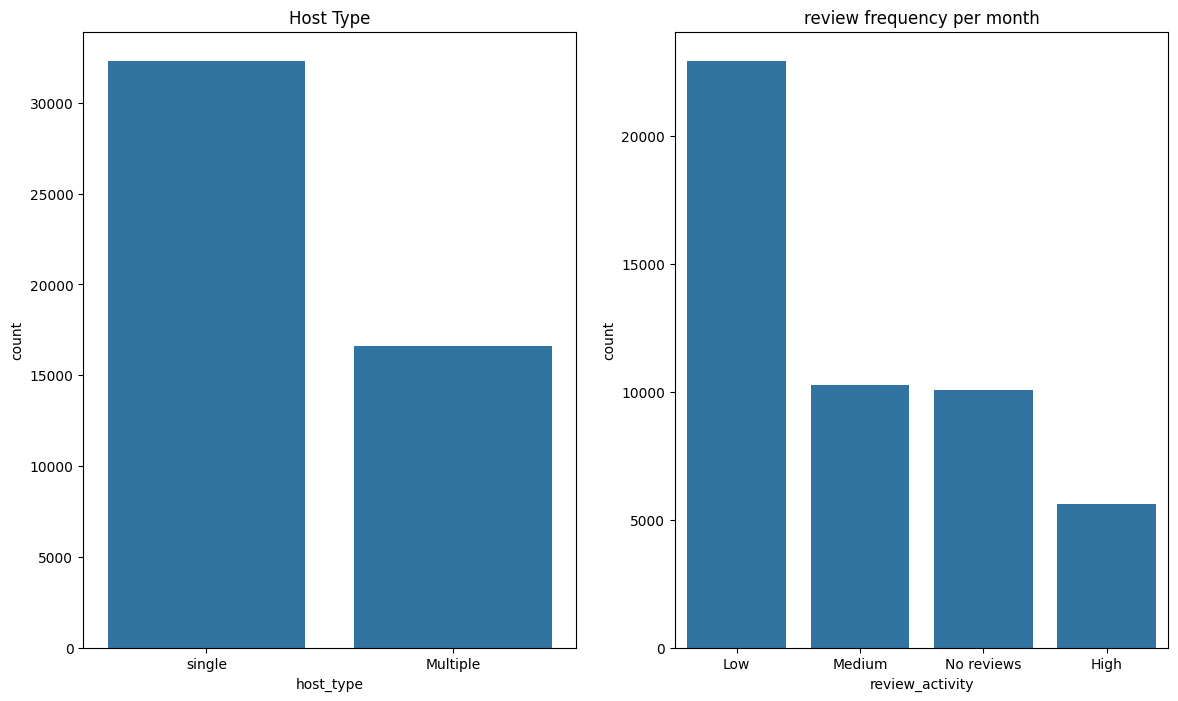

In [34]:
plt.figure(figsize=(14,8))

plt.subplot(1,2,1)
sns.countplot(data = df_clean, x = 'host_type', order = df_clean['host_type'].value_counts().index)
plt.title('Host Type')

plt.subplot(1,2,2)
sns.countplot(data = df_clean, x = 'review_activity', order = df_clean['review_activity'].value_counts().index)
plt.title('review frequency per month')

In [35]:
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,log_number_of_review,availability_365_ratio,price_category,min_night_category,availability_category,host_type,review_activity
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,2.302585,1.00,Mid - range,short stay,High,Multiple,Low
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,3.828641,0.97,Mid - range,short stay,High,Multiple,Low
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,0.000000,1.00,Mid - range,short stay,High,single,No reviews
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,5.602119,0.53,Budget,short stay,Medium,single,High
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,2.302585,0.00,Budget,long stay,Not available,single,Low


### Summary
- Derived Feature were created to capture meaningful pattern in the dataset.
- This include host behavior and listing engagement.
- Such feature provide deeper insights compared to raw numerical values.

# Feature Selection

In [36]:
df_final = df_clean[
[
    'neighbourhood_group',
    'room_type',
    'log_price',
    'availability_365_ratio',
    'host_type',
    'min_night_category',
    'price_category',
    'review_activity'
]
]

In [37]:
df_final.head()

,neighbourhood_group,room_type,log_price,availability_365_ratio,host_type,min_night_category,price_category,review_activity
0,Brooklyn,Private room,5.010635,1.00,Multiple,short stay,Mid - range,Low
1,Manhattan,Entire home/apt,5.420535,0.97,Multiple,short stay,Mid - range,Low
2,Manhattan,Private room,5.017280,1.00,single,short stay,Mid - range,No reviews
3,Brooklyn,Entire home/apt,4.499810,0.53,single,short stay,Budget,High
4,Manhattan,Entire home/apt,4.394449,0.00,single,long stay,Budget,Low


In [38]:
def feature_summary(df):
    summary = pd.DataFrame({
        'dtype' : df.dtypes,
        'missing_count' : df.isnull().sum(),
        'missing_percent' : (df.isnull().sum() / len(df)) * 100,
        'unique_values' : df.nunique(),
        'duplicate values': df.apply(lambda x: x.duplicated().sum()),
        'memory_MB' : df.memory_usage(index = False, deep = True) / (1024**2)
    })
    return summary.sort_values(by = 'missing_percent', ascending = False)

feature_summary(df_final)

,dtype,missing_count,missing_percent,unique_values,duplicate values,memory_MB
neighbourhood_group,object,0,0.0,5,48879,2.665816
room_type,object,0,0.0,3,48881,2.915370
log_price,float64,0,0.0,533,48351,0.372955
availability_365_ratio,float64,0,0.0,101,48783,0.372955
host_type,object,0,0.0,2,48882,2.595697
min_night_category,category,0,0.0,3,48881,0.046891
price_category,category,0,0.0,3,48881,0.046885
review_activity,category,0,0.0,4,48880,0.046992


## Summary
- In this step, I selected only the most useful features and removed the ones that were either repetitive or not very helpful. Features like `log_price`, `availability_ratio`, `host_type`, and the categorical groups were kept because they give better insights than the original raw data.
- The original columns such as price, availability_365, and minimum_nights were removed since they were already represented in a better form. I also dropped detailed location features like latitude and longitude to keep the dataset clean and easy to understand.
- The final dataset is now simpler, more meaningful, and ready for further analysis.

# conclusion

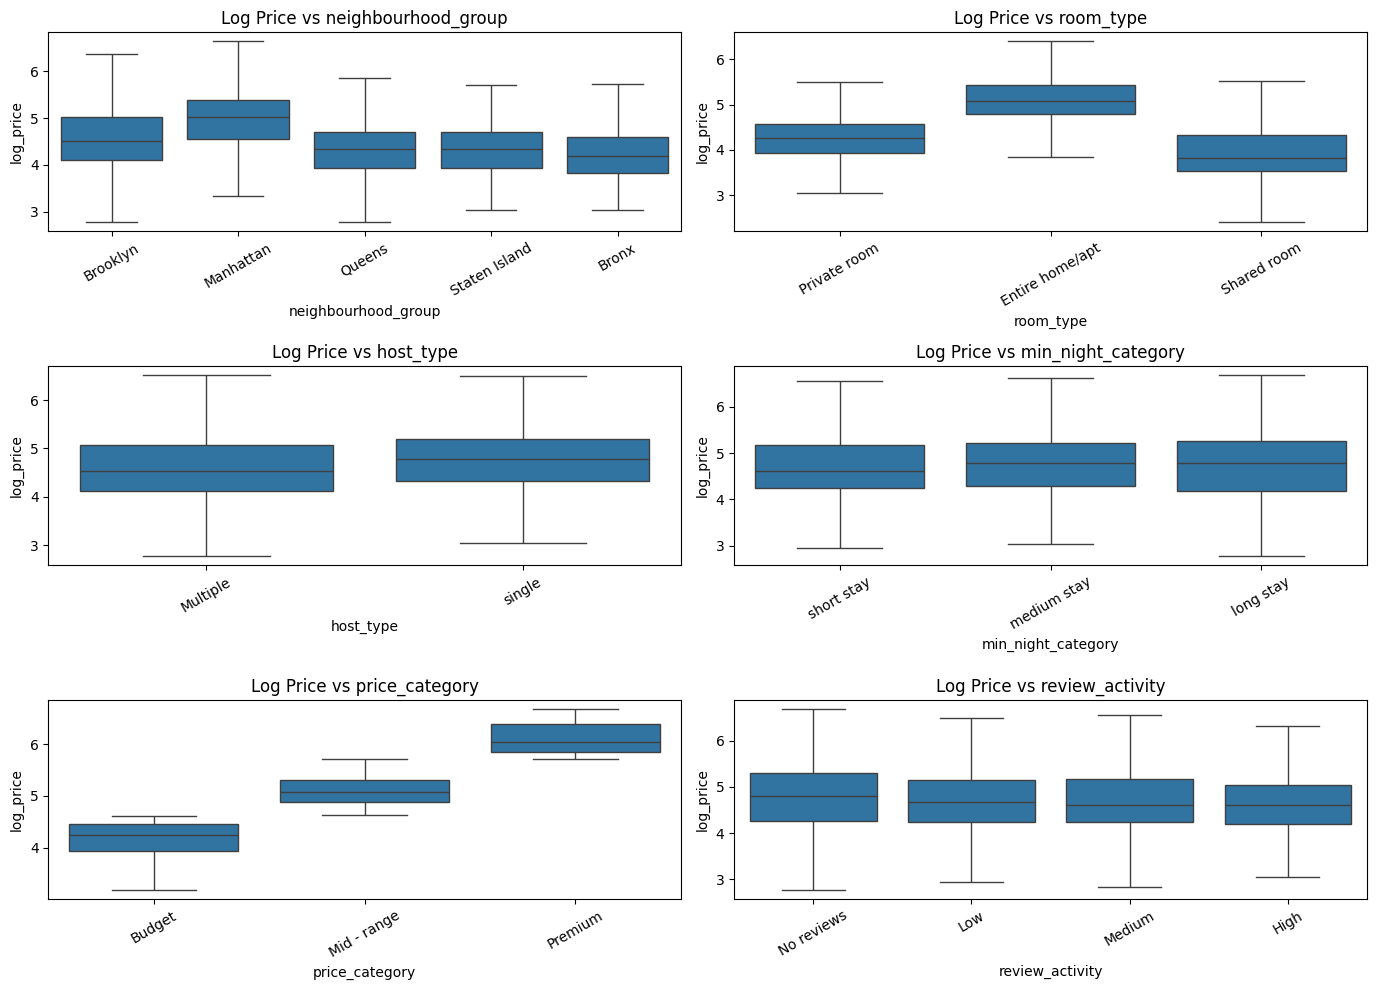

In [39]:
plt.figure(figsize=(14,10))

cat_cols = ['neighbourhood_group', 'room_type', 
            'host_type', 'min_night_category', 
            'price_category', 'review_activity']

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df_clean[col], y=df_clean['log_price'], showfliers=False)
    plt.title(f'Log Price vs {col}')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Summary
Airbnb prices are mainly driven by location and room type, while other factors like host activity and reviews have limited impact. The data shows real-world variation, and log transformation helps make the distribution more interpretable.

# Future Work
- In the future, this analysis can be extended by building machine learning models to predict listing prices or demand based on the engineered features.
- More advanced feature engineering can also be explored, such as combining location and demand indicators or using time-based data if available.
- Additionally, external data like seasonality, events, or tourism trends could be included to improve the analysis.
- Finally, this project can be turned into an interactive dashboard using tools like Streamlit or Power BI for better visualization and real-time insights.